In [1]:
import os
from pathlib import Path

import nibabel as nib
import nilearn.signal
import numpy as np
from matplotlib import pyplot as plt
from nisc.cifti import get_cifti_surf_data
from sklearn.preprocessing import scale
from tqdm import tqdm

In [2]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [3]:
HCP_TR = 0.72
NUM_VERTICES = 32492

project_root = Path(os.environ["PROJECT_ROOT"])
hcp_root = Path(os.environ["HCP_1200_DIR"])

test_filter_dir = project_root / "results/test_hcp_timeseries_filtering"
test_filter_dir.mkdir(exist_ok=True)

In [4]:
n_subs = 4

sub_list_path = (
    project_root / "resources/subject_lists/hcp_complete_data_867_subject_list.txt"
)
subjects = np.genfromtxt(sub_list_path, dtype=str)[:n_subs]
print(subjects)

['181131' '245333' '106824' '187547']


In [5]:
pattern = "rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii"

paths = {sub: next(iter((hcp_root / sub).rglob(pattern))) for sub in subjects}
print("\n".join(map(str, paths.values())))

/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/181131/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii
/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/245333/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii
/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/106824/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii
/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/187547/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii


In [6]:
def load_cifti(path: Path) -> np.ndarray:
    """Load cifti time series data."""
    data = nib.load(path)
    data = get_cifti_surf_data(data)
    data = np.ascontiguousarray(data.T)
    return data

In [7]:
scaled_series = {sub: scale(load_cifti(path)) for sub, path in paths.items()}

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [8]:
for sub, data in scaled_series.items():
    print(sub, data.shape)

181131 (1200, 64984)
245333 (1200, 64984)
106824 (1200, 64984)
187547 (1200, 64984)


In [9]:
# Get mask of vertices containing valid data
mask = np.std(scaled_series[subjects[0]], axis=0) > np.finfo(np.float16).eps
print(f"Mask size: {mask.sum()}/{mask.size} {mask.mean():.2f}")

Mask size: 59412/64984 0.91


In [10]:
# Get random sample vertices for testing and visualization
n_sample_vertices = 4096

rng = np.random.default_rng(42)
sample_indices = np.sort(
    rng.choice(mask.nonzero()[0], n_sample_vertices, replace=False)
)

print("Sample vertices:", sample_indices[:10].tolist())

Sample vertices: [77, 79, 108, 119, 175, 181, 182, 448, 902, 903]


In [11]:
def bandpass(series: np.ndarray, padtype: str = "odd") -> np.ndarray:
    valid_mask = np.std(series, axis=0) > np.finfo(np.float16).eps
    valid_series = series[:, valid_mask]

    clean_valid_series = nilearn.signal.clean(
        valid_series,
        standardize="zscore_sample",
        low_pass=0.08,
        high_pass=0.009,
        t_r=HCP_TR,
        butterworth__padtype=padtype,
    )

    clean_series = np.zeros_like(series, dtype=np.float32)
    clean_series[:, valid_mask] = clean_valid_series
    return clean_series

In [12]:
filtered_series_odd = {
    sub: bandpass(series[:, sample_indices], padtype="odd")
    for sub, series in tqdm(scaled_series.items())
}

  0%|                                                                    | 0/4 [00:00<?, ?it/s]

 25%|███████████████                                             | 1/4 [00:02<00:08,  2.86s/it]

 50%|██████████████████████████████                              | 2/4 [00:05<00:05,  2.85s/it]

 75%|█████████████████████████████████████████████               | 3/4 [00:08<00:02,  2.84s/it]

100%|████████████████████████████████████████████████████████████| 4/4 [00:11<00:00,  2.84s/it]

100%|████████████████████████████████████████████████████████████| 4/4 [00:11<00:00,  2.84s/it]

In [13]:
filtered_series_even = {
    sub: bandpass(series[:, sample_indices], padtype="even")
    for sub, series in tqdm(scaled_series.items())
}

  0%|                                                                    | 0/4 [00:00<?, ?it/s]

 25%|███████████████                                             | 1/4 [00:02<00:08,  2.79s/it]

 50%|██████████████████████████████                              | 2/4 [00:05<00:05,  2.80s/it]

 75%|█████████████████████████████████████████████               | 3/4 [00:08<00:02,  2.80s/it]

100%|████████████████████████████████████████████████████████████| 4/4 [00:11<00:00,  2.80s/it]

100%|████████████████████████████████████████████████████████████| 4/4 [00:11<00:00,  2.80s/it]

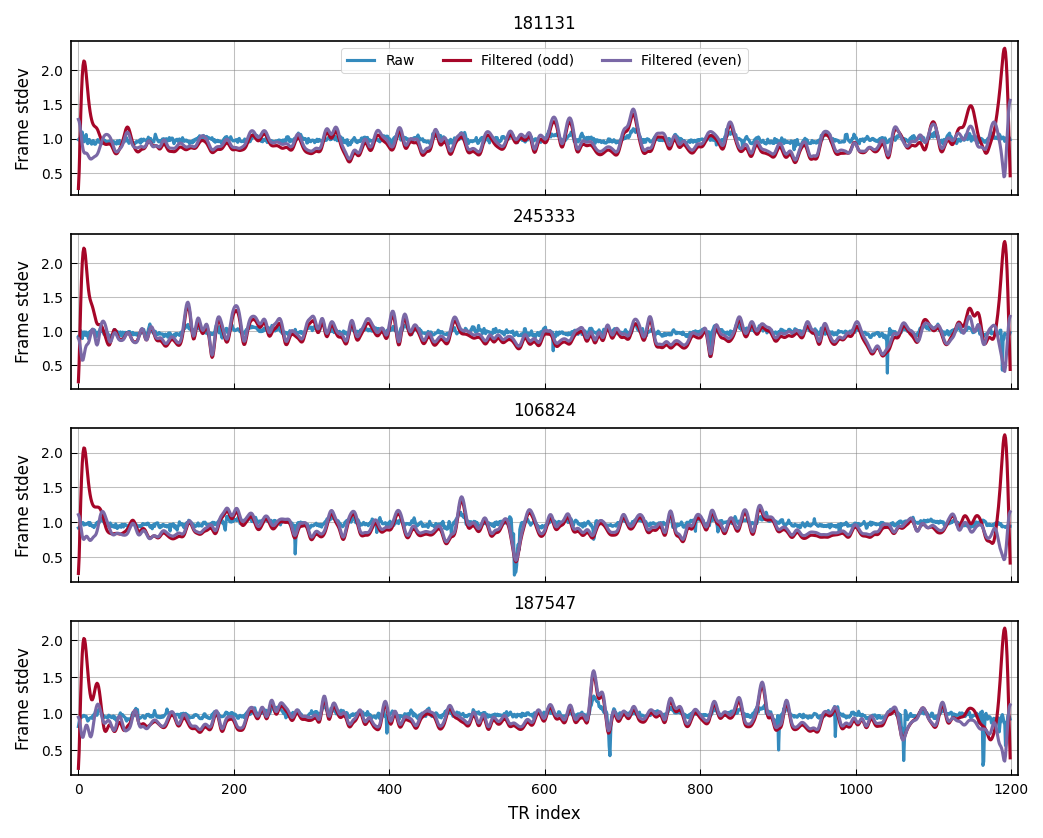

In [14]:
plotw = 2 * PLOTW
ploth = 0.4 * PLOTW
nr = len(subjects)
nc = 1

f, axs = plt.subplots(
    nr, nc, figsize=(nc * plotw, nr * ploth), sharex=True, layout="constrained"
)

for ii, sub in enumerate(subjects):
    plt.sca(axs[ii])
    std_series_scaled = np.std(scaled_series[sub][:, sample_indices], axis=1)
    std_series_filtered_odd = np.std(filtered_series_odd[sub], axis=1)
    std_series_filtered_even = np.std(filtered_series_even[sub], axis=1)
    plt.plot(std_series_scaled, label="Raw")
    plt.plot(std_series_filtered_odd, label="Filtered (odd)")
    plt.plot(std_series_filtered_even, label="Filtered (even)")
    plt.ylabel("Frame stdev")

    if ii == 0:
        plt.legend(loc="upper center", ncol=3)
    if ii == len(subjects) - 1:
        plt.xlabel("TR index")
    plt.title(sub)
    plt.xlim(-10, len(std_series_scaled) + 9)

plt.savefig(test_filter_dir / "hcp_frame_stdev_filter_pad_odd_even.png")